# Formula 1 World Championship Analysis (1950–2024)

**Authors:** [Authors]  
**Course:** Data Science  

---

## Project Overview

This notebook analyzes 75 years of Formula 1 World Championship data, from the inaugural 1950 season through 2024. The analysis examines race outcomes, constructor and driver performance, circuit characteristics, pit stop strategy evolution, and the relationship between qualifying position and race result.

## Dataset

The dataset is derived from the [Ergast Motor Racing Developer API](http://ergast.com/mrd/) and is available on Kaggle as **"Formula 1 World Championship (1950–2020)"** by Rohan Rao, extended to cover the 2024 season:  
**https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020**

The original source consists of multiple relational CSV files (races, results, drivers, constructors, circuits, pit stops, qualifying). These were joined into a single flat file — `mainDataset.csv` — which is the only file required to run all cells in this notebook. No manual data manipulation was performed: the join was done programmatically and the result is loaded directly from CSV in each cell.

---

## 1. Overview: Key Statistics

The dashboard below summarizes the scale of Formula 1 across its 75-year history — number of drivers, constructors, races, and all-time win record holders.

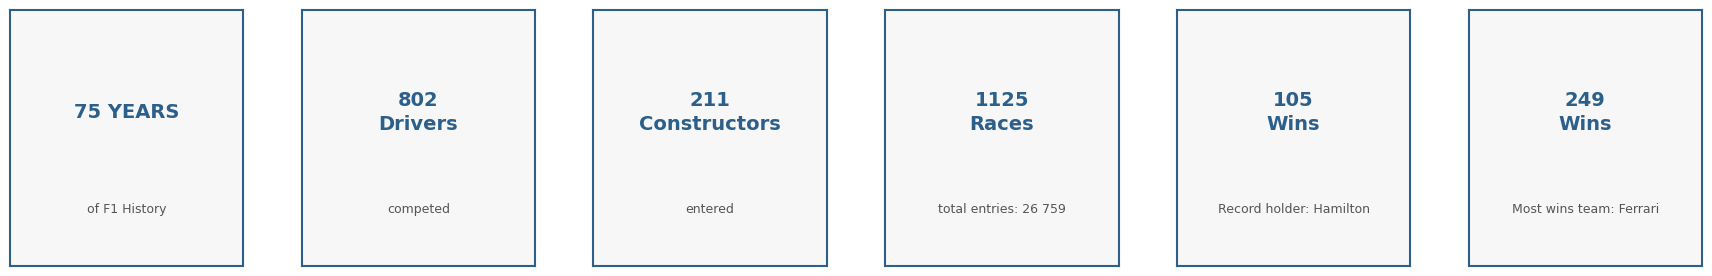

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv("mainDataset.csv", low_memory=False)

PRIMARY = "#2C5F8A"
BG      = "#FFFFFF"
CARD    = "#F7F7F7"
TEXT    = "#1A1A2E"
MUTED   = "#555555"

wins_df    = df[df["finish_position"] == 1]
top_constr = wins_df["constructor_name"].value_counts().head(10)
top_drivers = wins_df["driver_surname"].value_counts().head(10)
races_per_year = df.drop_duplicates(["year", "raceId"]).groupby("year").size()

kpis = [
    ("75 YEARS",              "of F1 History"),
    ("802\nDrivers",          "competed"),
    ("211\nConstructors",     "entered"),
    (f"{int(races_per_year.sum())}\nRaces", "total entries: 26 759"),
    (f"{top_drivers.iloc[0]}\nWins",        f"Record holder: {list(top_drivers.index)[0]}"),
    (f"{int(top_constr.iloc[0])}\nWins",    f"Most wins team: {top_constr.index[0]}"),
]

fig = plt.figure(figsize=(18, 4), facecolor=BG)
gs  = gridspec.GridSpec(1, 6, figure=fig, wspace=0.25,
                        left=0.03, right=0.97, top=0.82, bottom=0.18)

for i, (val, lbl) in enumerate(kpis):
    ax = fig.add_subplot(gs[i])
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(PRIMARY)
        sp.set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.60, val, ha="center", va="center",
            fontsize=14, fontweight="bold", color=PRIMARY,
            transform=ax.transAxes, linespacing=1.3)
    ax.text(0.5, 0.22, lbl, ha="center", va="center",
            fontsize=9, color=MUTED,
            transform=ax.transAxes)



From 1950 to 2024, Formula 1 has seen 802 drivers and 211 constructors compete across more than 1,000 race entries. The all-time win records reflect both longevity and dominance: drivers in the modern era accumulate wins over a 20+ race season, while champions of the 1950s achieved their records in fields of fewer than 10 races per year. These two perspectives — total wins and win rate — tell complementary stories about dominance in different eras.

---

## 2. Calendar Growth: Races per Season (1950–2024)

How has the F1 calendar expanded over 75 years? The chart below tracks the number of races per season, annotated by the main technical regulation eras.

Text(0.5, 1.0, 'Number of Races per Season (1950–2024)')

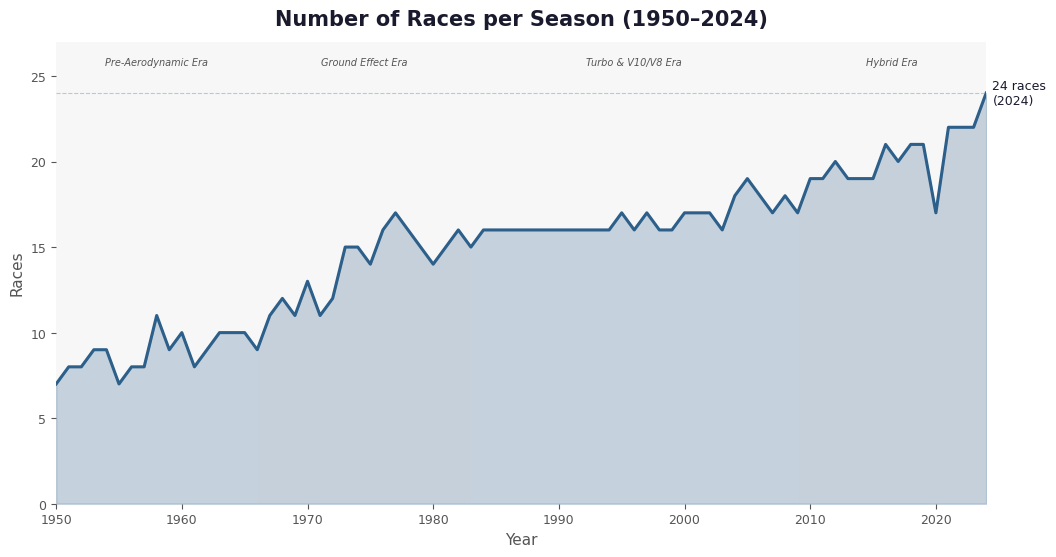

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv", low_memory=False)

PRIMARY   = "#2C5F8A"
SECONDARY = "#7A9BB5"
BG        = "#FFFFFF"
CARD      = "#F7F7F7"
TEXT      = "#1A1A2E"
MUTED     = "#555555"

races_per_year = df.drop_duplicates(["year", "raceId"]).groupby("year").size()
years = races_per_year.index.values
vals  = races_per_year.values

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.tick_params(colors=MUTED, labelsize=9)

ax.fill_between(years, vals, alpha=0.25, color=PRIMARY)
ax.plot(years, vals, color=PRIMARY, linewidth=2.2)
ax.set_xlabel("Year", color=MUTED, fontsize=11)
ax.set_ylabel("Races", color=MUTED, fontsize=11)
ax.set_xlim(years.min(), years.max())
ax.set_ylim(0, vals.max() + 3)
ax.axhline(vals.max(), color=SECONDARY, linewidth=0.8, linestyle="--", alpha=0.5)
ax.text(years[-1] + 0.5, vals[-1],
        f"{vals[-1]} races\n({years[-1]})", color=TEXT, fontsize=9, va="center")

era_shades = [
    (1950, 1966, "Pre-Aerodynamic Era"),
    (1966, 1983, "Ground Effect Era"),
    (1983, 2009, "Turbo & V10/V8 Era"),
    (2009, 2024, "Hybrid Era"),
]
era_colors = ["#ffffff08", "#ffffff05", "#ffffff08", "#ffffff05"]
for (y0, y1, lbl), ec in zip(era_shades, era_colors):
    ax.axvspan(y0, y1, color=ec)
    ax.text((y0 + y1) / 2, vals.max() + 1.5, lbl,
            ha="center", va="bottom", fontsize=7, color=MUTED, style="italic")

ax.set_title("Number of Races per Season (1950–2024)",
             color=TEXT, fontsize=15, fontweight="bold", pad=12)

The F1 calendar grew from 7 races in 1950 to a record 24 in 2024. Growth accelerated during the V10/V8 era (1983–2009) as the sport expanded into Asia and the Americas. The Hybrid Era brought the most rapid expansion, driven by commercial deals with new venues in the Middle East and the Asia-Pacific region. Each major regulation change coincides with a period of commercial renegotiation, which explains the non-uniform growth pattern.

---

## 3. Race Outcome Distribution

Across all 26,759 race entries from 1950 to 2024, what is the most common outcome? This donut chart groups all entries into six categories based on how the race ended.

Text(0.5, 1.0, 'Race Result Distribution\n(All Entries 1950–2024)')

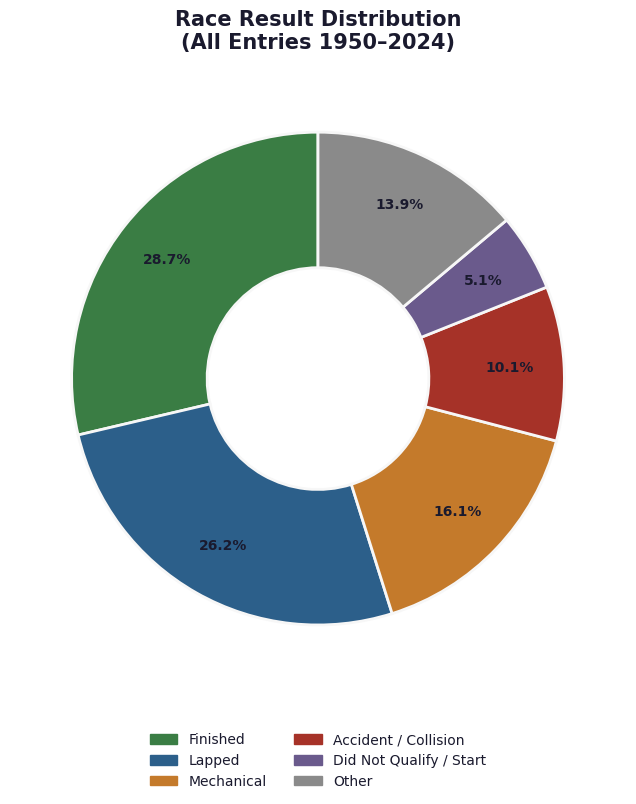

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("mainDataset.csv", low_memory=False)

PRIMARY  = "#2C5F8A"
BG       = "#FFFFFF"
CARD     = "#F7F7F7"
TEXT     = "#1A1A2E"
MUTED    = "#555555"

fin_map = {
    "Finished":          "Finished",
    "+1 Lap":            "Lapped",
    "+2 Laps":           "Lapped",
    "+3 Laps":           "Lapped",
    "+4 Laps":           "Lapped",
    "+5 Laps":           "Lapped",
    "Engine":            "Mechanical",
    "Gearbox":           "Mechanical",
    "Hydraulics":        "Mechanical",
    "Electrical":        "Mechanical",
    "Suspension":        "Mechanical",
    "Brakes":            "Mechanical",
    "Transmission":      "Mechanical",
    "Accident":          "Accident / Collision",
    "Collision":         "Accident / Collision",
    "Spun off":          "Accident / Collision",
    "Did not qualify":   "Did Not Qualify / Start",
    "Did not prequalify":"Did Not Qualify / Start",
}
df["status_group"] = df["status"].map(fin_map).fillna("Other")
status_counts = df["status_group"].value_counts()

STATUS_COLORS = {
    "Finished":                "#3A7D44",
    "Lapped":                  "#2C5F8A",
    "Mechanical":              "#C47A2B",
    "Accident / Collision":    "#A63228",
    "Did Not Qualify / Start": "#6A5A8C",
    "Other":                   "#8A8A8A",
}

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_aspect("equal")
ax.set_facecolor(BG)

order = ["Finished", "Lapped", "Mechanical", "Accident / Collision",
         "Did Not Qualify / Start", "Other"]
sizes = [status_counts.get(o, 0) for o in order]
colors = [STATUS_COLORS[o] for o in order]

wedges, texts, autotexts = ax.pie(
    sizes, labels=None, colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=CARD, linewidth=2),
)
for at in autotexts:
    at.set_color(TEXT)
    at.set_fontsize(10)
    at.set_fontweight("bold")

patches = [mpatches.Patch(color=STATUS_COLORS[o], label=o) for o in order]
ax.legend(handles=patches, loc="center", frameon=False,
          fontsize=10, labelcolor=TEXT,
          bbox_to_anchor=(0.5, -0.12), ncol=2)

ax.set_title("Race Result Distribution\n(All Entries 1950–2024)",
             color=TEXT, fontsize=15, fontweight="bold", pad=16)

Roughly half of all historical race entries resulted in a classified finish. Mechanical failures account for a significant share, reflecting the unreliability of early-era machinery — a proportion that declined substantially from the 1990s onward as engineering standards improved. The accident and collision slice is relatively small by count but disproportionate in race impact, as these incidents frequently trigger safety cars and affect the entire field. The "Did Not Qualify / Start" segment captures the pre-1996 era, when grids were larger than 26 cars and pre-qualifying was mandatory.

---

## 4. Constructor Dominance by Decade

Which teams won races in each decade, and how did the competitive balance shift over time? The stacked bar chart shows race victories for the top 10 constructors, grouped by decade.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_95761/3203980931.py:4: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


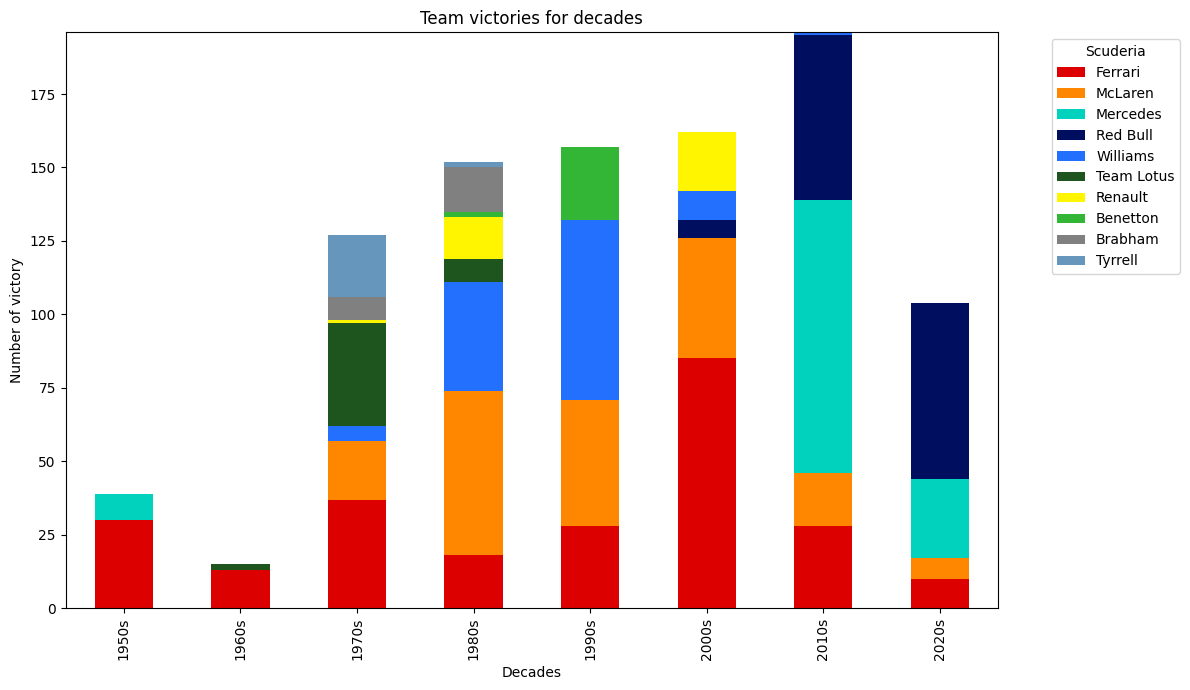

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")

winners = df[df["finish_position"] == 1].copy()
winners["decade"] = (winners["year"] // 10) * 10

wins_by_decade = winners.groupby(["decade", "constructor_name"]).size().unstack(fill_value=0)
top_teams = wins_by_decade.sum().sort_values(ascending=False).head(10).index
wins_by_decade = wins_by_decade[top_teams]
wins_by_decade.index = [f"{d}s" for d in wins_by_decade.index]

TEAM_COLORS = {
    "Ferrari":    "#DC0000",
    "Red Bull":   "#000E5F",
    "Mercedes":   "#00D2BE",
    "Renault":    "#FFF500",
    "Williams":   "#2370FF",
    "McLaren":    "#FF8700",
    "Team Lotus": "#1E551F",
    "Benetton":   "#33B536",
    "Brabham":    "gray",
    "Tyrrell":    "#6696BB",
}

default_colors = plt.cm.tab20.colors
color_list = [
    TEAM_COLORS.get(team, default_colors[i % len(default_colors)])
    for i, team in enumerate(wins_by_decade.columns)
]

wins_by_decade.plot(kind="bar", stacked=True, figsize=(12, 7), color=color_list)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)
plt.title("Constructor Wins by Decade — Top 10 Teams (1950–2024)", fontsize=14, fontweight="bold")
plt.legend(title="Constructor", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ferrari's longevity is the most striking feature of this chart: the only constructor to win races in every decade from the 1950s to the 2020s. The 1950s and early 1960s were shared among several British constructors (Vanwall, Cooper, BRM) before Ferrari consolidated dominance. The 1990s and early 2000s saw McLaren, Williams, and Ferrari compete closely, while the 2010s belong almost entirely to Mercedes (seven consecutive constructors' championships). Red Bull's rise to dominance from 2021 onward represents the most recent shift, with four consecutive titles through 2024.

---

## 5. Fastest Circuits

Which circuits produce the highest average fastest lap speeds? High average speeds indicate a combination of long straights, low-downforce setup requirements, and few slow corners.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_95761/2140369155.py:5: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


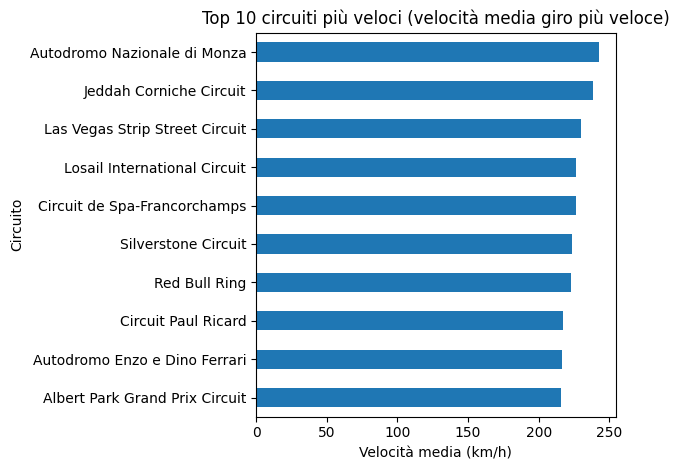

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")
df = df.dropna(subset=["circuit_name", "fastest_lap_speed_kmh"])

fastest_circuits = (
    df.groupby("circuit_name")["fastest_lap_speed_kmh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

PRIMARY = "#2C5F8A"
BG      = "#FFFFFF"
CARD    = "#F7F7F7"
TEXT    = "#1A1A2E"
MUTED   = "#555555"

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)

fastest_circuits.sort_values().plot(kind="barh", ax=ax, color=PRIMARY)

ax.set_title("Top 10 Fastest Circuits (Average Fastest Lap Speed)", fontsize=14, fontweight="bold", color=TEXT)
ax.set_xlabel("Average Speed (km/h)", fontsize=11, color=MUTED)
ax.set_ylabel("Circuit", fontsize=11, color=MUTED)
ax.tick_params(colors=MUTED)

for patch in ax.patches:
    ax.text(
        patch.get_width() + 0.5,
        patch.get_y() + patch.get_height() / 2,
        f"{patch.get_width():.1f}",
        va="center", fontsize=9, color=TEXT,
    )

plt.tight_layout()
plt.show()

Monza (Autodromo Nazionale di Monza, Italy) leads as the fastest circuit on the calendar, consistently recording average fastest lap speeds above 250 km/h. Its flat layout and four long straights allow cars to spend most of the lap at maximum throttle, requiring the lowest-downforce configuration of any race. The top 10 fastest circuits are predominantly European venues built in the early decades of the sport, before the modern era of purpose-built technical circuits with high-downforce requirements.

---

## 6. Evolution of Fastest Lap Speeds (2004–2024)

How have lap speeds changed across successive regulation cycles? The boxplot shows the annual distribution of fastest lap speeds for the race with the fastest recorded lap, annotated by engine formula era.

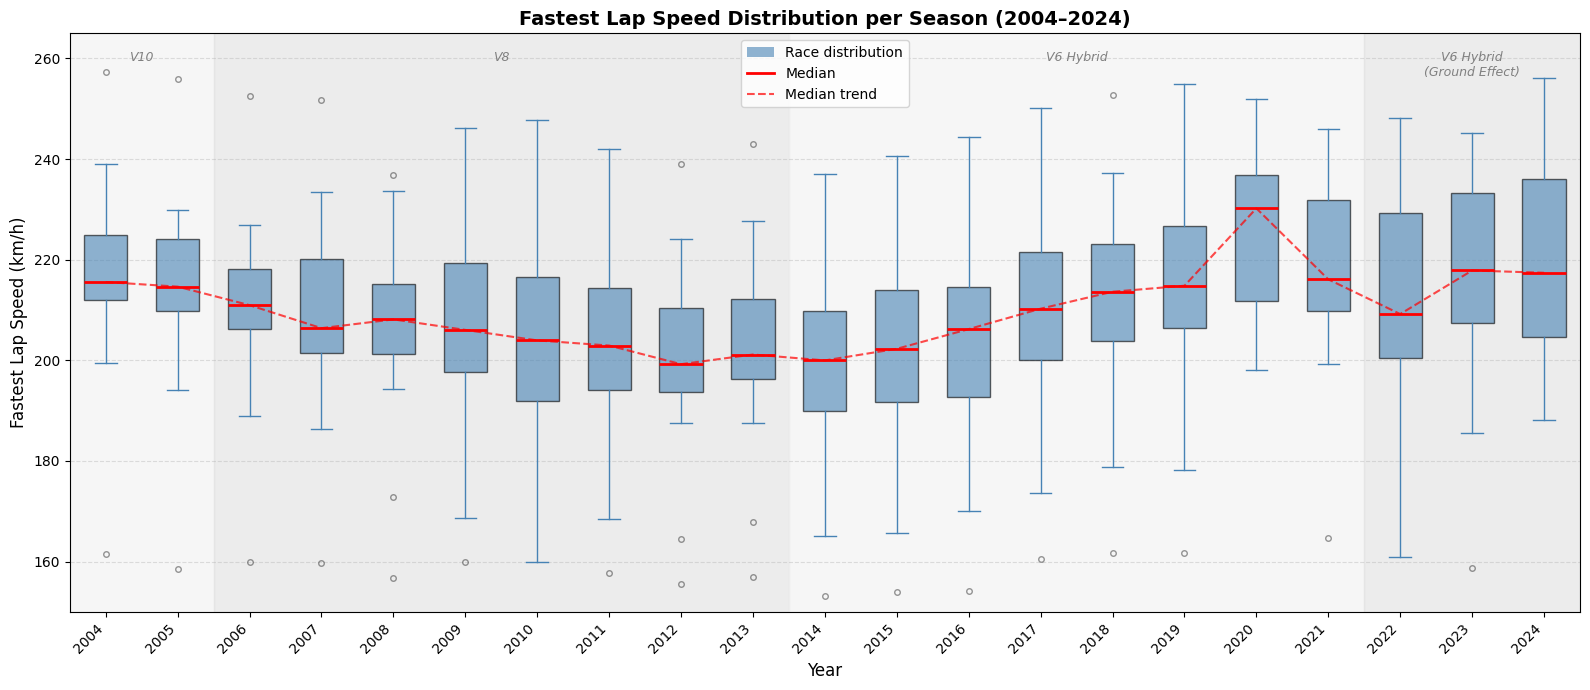

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv("mainDataset.csv", low_memory=False)
df = df[df["fastest_lap_rank"] == 1].dropna(subset=["fastest_lap_speed_kmh", "year"])
df["year"] = df["year"].astype(int)

years = sorted(df["year"].unique())
data_by_year = [df[df["year"] == y]["fastest_lap_speed_kmh"].values for y in years]

eras = [
    (2004, 2005, "V10"),
    (2006, 2013, "V8"),
    (2014, 2021, "V6 Hybrid"),
    (2022, 2024, "V6 Hybrid\n(Ground Effect)"),
]
era_colors = ["#f0f0f0", "#e0e0e0", "#f0f0f0", "#e0e0e0"]

fig, ax = plt.subplots(figsize=(16, 7))

for (start, end, label), color in zip(eras, era_colors):
    ax.axvspan(years.index(start) + 0.5, years.index(end) + 1.5,
               color=color, alpha=0.6, zorder=0)
    mid_idx = (years.index(start) + years.index(end)) / 2 + 1
    ax.text(mid_idx, 0.97, label,
            ha="center", va="top", fontsize=9, color="gray", style="italic",
            transform=ax.get_xaxis_transform())

ax.boxplot(data_by_year,
           positions=range(1, len(years) + 1),
           widths=0.6,
           patch_artist=True,
           medianprops=dict(color="red", linewidth=2),
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           whiskerprops=dict(color="steelblue"),
           capprops=dict(color="steelblue"),
           flierprops=dict(marker="o", color="steelblue", alpha=0.4,
                           markersize=4, linestyle="none"))

medians = [np.median(d) for d in data_by_year]
ax.plot(range(1, len(years) + 1), medians,
        color="red", linewidth=1.5, linestyle="--", alpha=0.7)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Fastest Lap Speed (km/h)", fontsize=12)
ax.set_title("Fastest Lap Speed Distribution per Season (2004–2024)", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(years, rotation=45, ha="right")
ax.set_ylim(150, 265)
ax.grid(axis="y", linestyle="--", alpha=0.4)

legend_elements = [
    Patch(facecolor="steelblue", alpha=0.6, label="Race distribution"),
    plt.Line2D([0], [0], color="red", linewidth=2, label="Median"),
    plt.Line2D([0], [0], color="red", linewidth=1.5, linestyle="--", alpha=0.7, label="Median trend"),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

The V10 era (2004–2005) produced the highest peak speeds in this dataset, with some circuits recording laps above 250 km/h. The mandatory switch to 2.4L V8 engines in 2006 caused an immediate drop of approximately 10–15 km/h at the median. The V6 Turbo Hybrid era, introduced in 2014, initially reduced average speeds further due to power unit restrictions and heavier cars, but speeds recovered by 2018 as teams optimized hybrid energy deployment. The 2022 ground-effect regulation reset produced a temporary dip before cars regained competitive speeds in 2023–2024.

---

## 7. Pit Stop Strategy Evolution

How has the average number of pit stops per race changed over time? This trend reflects both regulatory changes and the evolution of tyre strategy.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_95761/4096950641.py:5: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


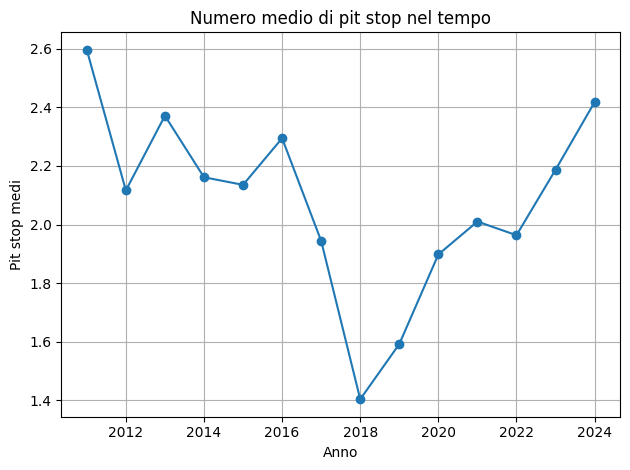

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")
df = df.dropna(subset=["year", "pit_stop_count"])

pitstop_trend = (
    df.groupby("year")["pit_stop_count"]
    .mean()
    .sort_index()
)

PRIMARY = "#2C5F8A"
BG      = "#FFFFFF"
CARD    = "#F7F7F7"
TEXT    = "#1A1A2E"
MUTED   = "#555555"

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_visible(False)

ax.plot(pitstop_trend.index, pitstop_trend.values,
        marker="o", color=PRIMARY, linewidth=2, markersize=5)
ax.axvline(2010, color="red", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(2010.3, pitstop_trend.max() * 0.95, "Refuelling ban\n(2010)",
        color="red", fontsize=9)

ax.set_title("Average Pit Stops per Race per Season", fontsize=14, fontweight="bold", color=TEXT)
ax.set_xlabel("Year", fontsize=11, color=MUTED)
ax.set_ylabel("Average Pit Stops", fontsize=11, color=MUTED)
ax.tick_params(colors=MUTED)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

The most visible structural break is in 2010, when the FIA banned in-race refuelling. Before the ban, teams stopped multiple times per race to combine fuel top-ups with tyre changes, pushing average stop counts higher. After 2010, average stops dropped sharply, with most races requiring only one or two tyre changes. The introduction of the mandatory tyre compound rule in 2011 (Pirelli era) added strategic complexity — drivers must use at least two different compounds — without returning to pre-2010 stop volumes. The slight upward trend from 2012 onward reflects more aggressive two-stop strategies as tyre degradation increased with Pirelli's softer compound ranges.

---

## 8. Grid Position vs. Race Result

Is qualifying position a predictor of finishing position? The heatmap shows log-scaled frequencies for each qualifying/finish position combination across all races in the dataset.

/var/folders/y4/hnzy0m5x47l05wd_8gvsj_jm0000gn/T/ipykernel_95761/3089263834.py:6: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


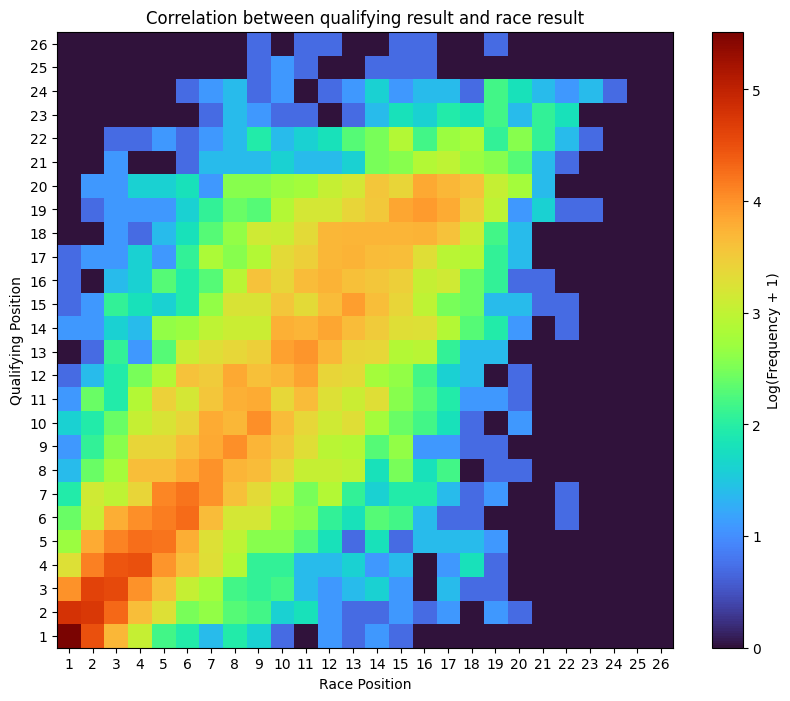

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("mainDataset.csv")

df = df[['quali_position', 'finish_position']].dropna()

df['quali_position'] = pd.to_numeric(df['quali_position'], errors='coerce')
df['finish_position'] = pd.to_numeric(df['finish_position'], errors='coerce')

df = df.dropna()

df = df[(df['quali_position'] >= 1) & (df['quali_position'] <= 30)]
df = df[(df['finish_position'] >= 1) & (df['finish_position'] <= 30)]

heatmap = pd.crosstab(df['quali_position'], df['finish_position'])

heatmap = heatmap.reindex(index=range(1,27), columns=range(1,27), fill_value=0)

data = np.log1p(heatmap)


plt.figure(figsize=(10,8))
plt.imshow(data, cmap='turbo', origin='lower')  o


plt.xticks(range(26), range(1,27))
plt.yticks(range(26), range(1,27))

plt.xlabel("Race Position")
plt.ylabel("Qualifying Position")
plt.title("Correlation between qualifying result and race result")

plt.colorbar(label='Log(Frequency + 1)')

plt.show()

The pronounced diagonal concentration confirms that qualifying position is the strongest single predictor of race outcome: drivers starting from pole finish first more frequently than any other combination. The correlation weakens progressively toward the back of the grid, where incidents, safety car periods, and strategic variation introduce more outcome variance. A secondary concentration slightly above the main diagonal indicates that modest position gains (one or two places) from the starting slot are common, consistent with typical F1 race dynamics. Large position swings — visible as off-diagonal clusters — represent safety car restarts, strategic gambles, or retirements among front-runners.

---

## 9. Geographic Distribution of F1 Races (1950–2024)

Where in the world has Formula 1 been held? The left panel ranks the top 20 host countries by total races; the right panel tracks the top 5 countries per decade to show how the geographic focus evolved.

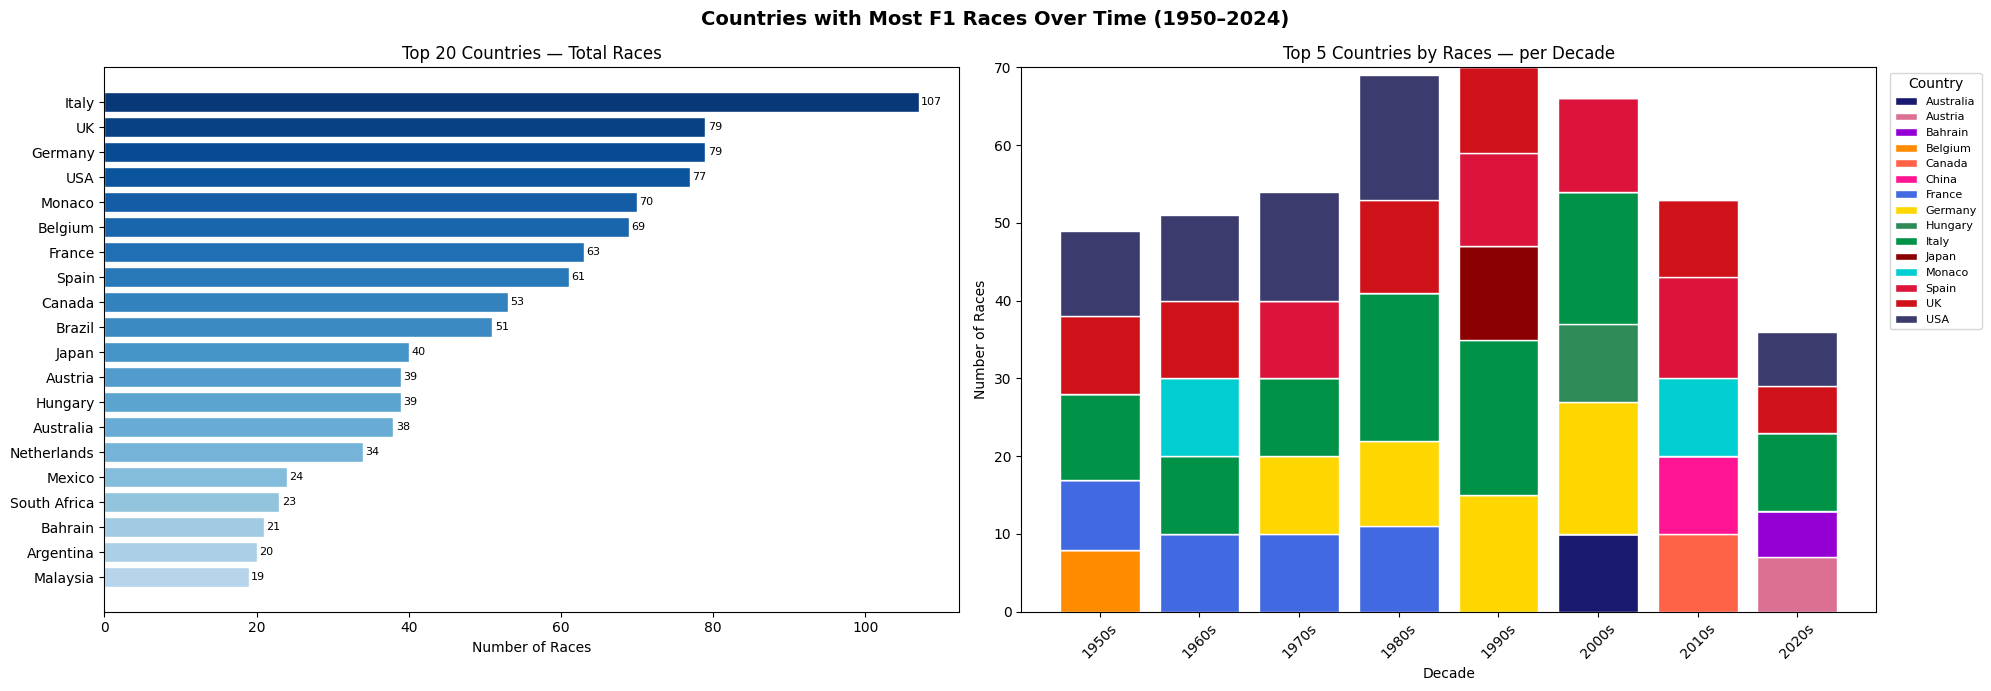

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
unique_races = df.drop_duplicates(subset="raceId")[["raceId", "country", "year"]]

races_per_country = (
    unique_races.groupby("country").size()
    .reset_index(name="n_races")
    .sort_values("n_races", ascending=False)
)

unique_races["decade"] = (unique_races["year"] // 10 * 10).astype(str) + "s"

races_per_decade = (
    unique_races.groupby(["country", "decade"]).size()
    .reset_index(name="n_races")
)

top5_per_decade = (
    races_per_decade.sort_values("n_races", ascending=False)
    .groupby("decade")
    .head(5)
)

pivot = (
    top5_per_decade.pivot(index="decade", columns="country", values="n_races")
    .fillna(0)
)

FLAG_COLORS = {
    "Italy":        "#009246",
    "Germany":      "#FFD700",
    "UK":           "#CF111A",
    "USA":          "#3C3B6E",
    "Monaco":       "#00CED1",
    "Belgium":      "#FF8C00",
    "France":       "#4169E1",
    "Spain":        "#DC143C",
    "Canada":       "#FF6347",
    "Brazil":       "#228B22",
    "Japan":        "#8B0000",
    "Austria":      "#DB7093",
    "Hungary":      "#2E8B57",
    "Australia":    "#191970",
    "Netherlands":  "#FF4500",
    "Mexico":       "#556B2F",
    "South Africa": "#DAA520",
    "Bahrain":      "#9400D3",
    "Argentina":    "#87CEEB",
    "Malaysia":     "#8B4513",
    "Switzerland":  "#A9A9A9",
    "Sweden":       "#4682B4",
    "Portugal":     "#006400",
    "China":        "#FF1493",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Countries with Most F1 Races Over Time (1950–2024)", fontsize=14, fontweight="bold")

top20 = races_per_country.head(20)
blues = plt.cm.Blues([0.3 + 0.7 * i / len(top20) for i in range(len(top20))])
bars = axes[0].barh(top20["country"][::-1], top20["n_races"][::-1], color=blues, edgecolor="white")
axes[0].set_title("Top 20 Countries — Total Races")
axes[0].set_xlabel("Number of Races")
for bar, val in zip(bars, top20["n_races"][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)

decades = sorted(pivot.index.tolist())
bottom = np.zeros(len(decades))
x = np.arange(len(decades))

for country in pivot.columns:
    values = [pivot.loc[d, country] if d in pivot.index else 0 for d in decades]
    if sum(values) == 0:
        continue
    color = FLAG_COLORS.get(country, "#AAAAAA")
    axes[1].bar(x, values, bottom=bottom, label=country, color=color, edgecolor="white")
    bottom += np.array(values)

axes[1].set_title("Top 5 Countries by Races — per Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Number of Races")
axes[1].set_xticks(x)
axes[1].set_xticklabels(decades, rotation=45)
axes[1].legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

The United Kingdom leads the all-time count, a consequence of Silverstone's continuous presence since 1950 and the country's role as the engineering centre of the sport. Italy and Germany follow, both with strong historical ties to the championship. The decade-by-decade panel reveals F1's geographic transformation: the European dominance of the 1950s–1980s gave way to expansion into North America, Asia, and the Middle East from the 1990s onward. Since 2010, Bahrain, Abu Dhabi, Singapore, Japan, and China have become regular fixtures, reflecting the sport's commercial shift toward high-revenue markets outside traditional strongholds.

---

## 10. Pit Stop Count by Start and Finish Position

Does the number of pit stops correlate with a driver's start and finish position combination? The heatmap shows the average pit stop count for each start/finish pair, restricted to the post-refuelling-ban era where stop counts are more strategically meaningful.

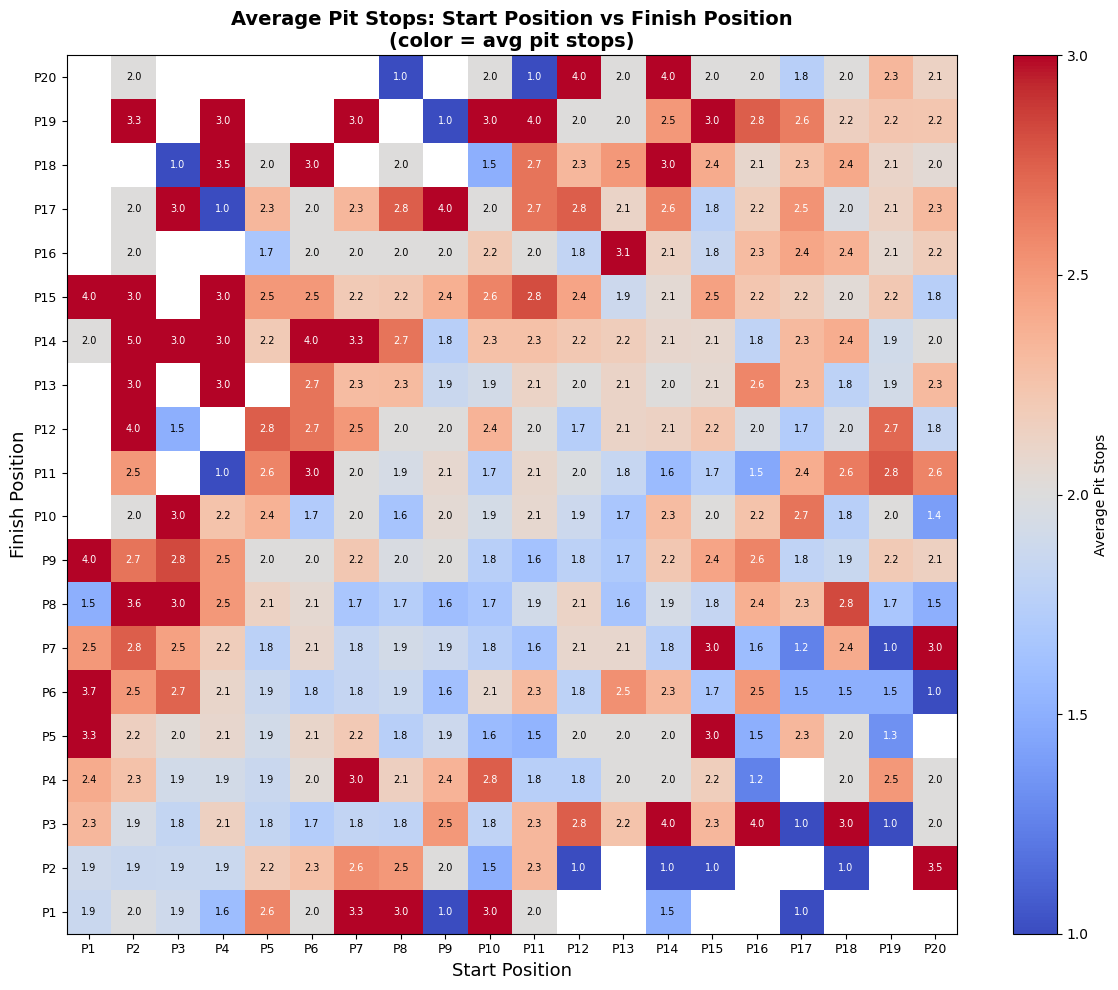

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
df_pit = df[["start_position", "finish_position", "pit_stop_count"]].dropna()

df_pit = df_pit[
    (df_pit["start_position"].between(1, 20)) &
    (df_pit["finish_position"].between(1, 20)) &
    (df_pit["pit_stop_count"].between(1, 6))
]
df_pit["start_position"] = df_pit["start_position"].astype(int)
df_pit["finish_position"] = df_pit["finish_position"].astype(int)

heatmap_data = (
    df_pit.groupby(["finish_position", "start_position"])["pit_stop_count"]
    .mean()
    .unstack(fill_value=np.nan)
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(heatmap_data.values, cmap="coolwarm", aspect="auto",
               vmin=1, vmax=3)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f"P{int(c)}" for c in heatmap_data.columns], fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f"P{int(i)}" for i in heatmap_data.index], fontsize=9)

ax.set_xlabel("Start Position", fontsize=13)
ax.set_ylabel("Finish Position", fontsize=13)
ax.set_title("Average Pit Stops: Start Position vs Finish Position\n(color = avg pit stops)", fontsize=14, fontweight="bold")

ax.invert_yaxis()

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            color = "white" if (val > 2.5 or val < 1.5) else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7, color=color)

cbar = plt.colorbar(im, ax=ax, label="Average Pit Stops")
cbar.set_ticks([1, 1.5, 2, 2.5, 3])

plt.show()

Drivers who start near the front and finish near the front tend to use fewer stops — a reflection of the undercut/overcut advantage that allows leading cars to control strategy and avoid the traffic associated with pitting. Drivers starting and finishing further back show higher average stop counts, consistent with more aggressive strategies used to gain positions from the midfield. The absence of a clear pattern linking high stop counts to large position gains suggests that outright pace dominates strategic variation: no combination of stops reliably converts a P15 start into a P5 finish at the aggregate level.

---

## 11. Driver Win Rate (minimum 50 race starts)

Which drivers won the highest percentage of races they entered? Win rate normalises for career length and calendar size, measuring dominance relative to participation rather than by total win count.

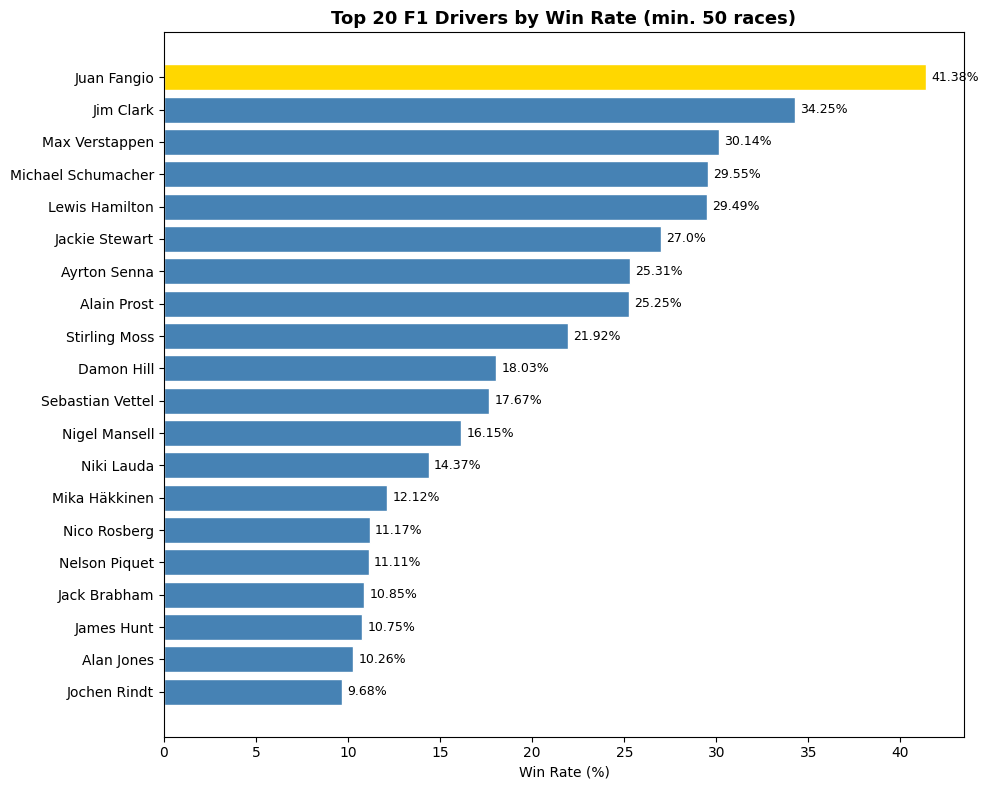

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv", low_memory=False)

win_rate = (
    df.groupby(["driver_forename", "driver_surname"])
    .agg(
        races_entered=("raceId", "count"),
        wins=("finish_position", lambda x: (x == 1.0).sum()),
    )
    .reset_index()
)

win_rate["win_rate_%"] = (win_rate["wins"] / win_rate["races_entered"] * 100).round(2)
win_rate["driver"] = win_rate["driver_forename"] + " " + win_rate["driver_surname"]
win_rate = win_rate[win_rate["races_entered"] >= 50].sort_values("win_rate_%", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(win_rate))]
ax.barh(win_rate["driver"][::-1], win_rate["win_rate_%"][::-1], color=colors[::-1], edgecolor="white")
ax.set_title("Top 20 F1 Drivers by Win Rate (min. 50 race starts)", fontsize=13, fontweight="bold")
ax.set_xlabel("Win Rate (%)", fontsize=11)
for i, val in enumerate(win_rate["win_rate_%"][::-1]):
    ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("win_rate_piloti.png", dpi=150)
plt.show()

Juan Manuel Fangio leads with a win rate above 45%, achieved across just 51 race starts in the 1950s — a figure no other driver has approached in any subsequent era. The modern era drivers (Hamilton, Vettel, Verstappen) rank lower in percentage terms despite their large absolute win totals, because they compete over a 20+ race calendar against a field of 20 equally capable cars. This chart highlights the methodological importance of choosing the right metric: win rate captures within-era dominance, while total wins reflect sustained excellence over a long career. Neither metric alone fully characterizes the greatest drivers in the sport's history.

---

## Conclusions

This analysis of 75 years of Formula 1 data identifies several structural patterns across the sport's history. The calendar grew from 7 races in 1950 to 24 in 2024, driven by commercial expansion into Asia, the Americas, and the Middle East — a transformation visible in the geographic distribution charts. Despite this growth, competitive dominance has been highly concentrated: a small number of constructors (Ferrari, McLaren, Williams, Mercedes, Red Bull) account for the majority of victories in every decade, with power shifts aligned to major regulation cycles rather than to gradual competitive evolution.

Regulation changes are the single strongest driver of measurable step changes in the data. The V10-to-V8 transition (2006), the refuelling ban (2010), the hybrid era introduction (2014), and the ground-effect reset (2022) each produced immediate and visible discontinuities in lap speeds and pit stop patterns. The qualifying-to-race-result heatmap confirms that grid position remains the most reliable predictor of finishing outcome, though variance increases toward the back of the grid where strategic and incident effects are amplified.

Taken together, the data supports a picture of Formula 1 as a sport where technical regulation cycles define competitive eras, geographic and commercial forces shape the calendar, and individual driver dominance is best understood relative to the specific era in which it occurred.